In [1]:
import os
import json
from zipfile import ZipFile
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [2]:
kaggle =  json.load(open('kaggle.json'))

In [3]:
# 3 SETTING UP KAGGLE API AS ENVIRONMENT VARIABLES


os.environ['KAGGLE_USERNAME'] = kaggle['username']
os.environ['KAGGLE_KEY'] = kaggle['key']

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Path to dataset files: /kaggle/input/plantvillage-dataset


In [5]:
print(os.listdir(path))

['plantvillage dataset']


In [6]:
print(len(os.listdir(os.path.join(path, 'plantvillage dataset/color'))))
print(os.listdir(os.path.join(path, 'plantvillage dataset/color'))[:5])

print(len(os.listdir(os.path.join(path, 'plantvillage dataset/grayscale'))))
print(os.listdir(os.path.join(path, 'plantvillage dataset/grayscale'))[:5])

print(len(os.listdir(os.path.join(path, 'plantvillage dataset/segmented'))))
print(os.listdir(os.path.join(path, 'plantvillage dataset/segmented'))[:5])

38
['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy']
38
['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy']
38
['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy']


In [7]:
# dataset path

color_dir = os.path.join(path, 'plantvillage dataset/color')
grayscale_dir = os.path.join(path, 'plantvillage dataset/grayscale')
segmented_dir = os.path.join(path, 'plantvillage dataset/segmented')

Displaying image from: /kaggle/input/plantvillage-dataset/plantvillage dataset/color/Potato___Early_blight/df7e4d39-fb74-4e6d-9d32-04d7d2165135___RS_Early.B 6700.JPG


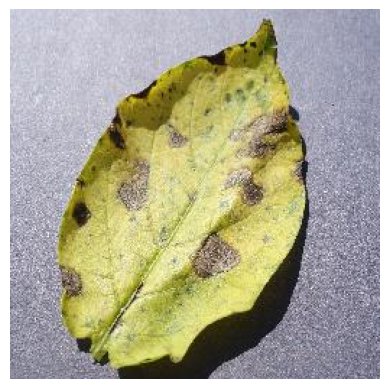

In [8]:
import random

# Get a list of subdirectories (classes) in the color_dir
class_dirs = os.listdir(color_dir)

# Choose a random class directory
random_class = random.choice(class_dirs)

# Get a list of images in the chosen class directory
images_in_class = os.listdir(os.path.join(color_dir, random_class))

# Choose a random image from that class
random_image = random.choice(images_in_class)

# Construct the full image path
img_path = os.path.join(color_dir, random_class, random_image)

print(f"Displaying image from: {img_path}")

#reading the img
img = mpimg.imread(img_path)

#display the img
plt.imshow(img)
plt.axis('off')
plt.show()

In [9]:
# image parameters

img_size = 224
batch_size = 32

In [10]:
# image data generator

data_gen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

In [11]:
# train generator

train_generator = data_gen.flow_from_directory(
    color_dir,
    target_size = (img_size, img_size),
    batch_size = batch_size,
    class_mode = 'categorical',
    subset = 'training'
)

Found 43456 images belonging to 38 classes.


In [12]:
# validation generator

validation_generator = data_gen.flow_from_directory(
    color_dir,
    target_size = (img_size, img_size),
    batch_size = batch_size,
    class_mode = 'categorical',
    subset = 'validation'
)

Found 10849 images belonging to 38 classes.


In [13]:
# model definition
def build_model(img_size, num_classes):

    model = models.Sequential([

        # Input Layer
        layers.Input(shape=(img_size, img_size, 3)),

        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Reduce dimensions smartly
        layers.GlobalAveragePooling2D(),

        # Fully Connected
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        # Output Layer
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

In [14]:
# model summary

img_size = 224
num_classes = len(train_generator.class_indices)

model = build_model(img_size, num_classes)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,558 (451.40 KB)

 Trainable params: 115,110 (449.65 KB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
# compiling of the model :

# compile() tells the model---
# “This is how you should learn.”

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    train_generator,
    steps_per_epoch = train_generator.samples // batch_size,
    epochs = 5,
    validation_data = validation_generator,
    validation_steps = validation_generator.samples // batch_size
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 363s 261ms/step - accuracy: 0.4844 - loss: 1.8798 - val_accuracy: 0.6918 - val_loss: 1.0243
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 105s 77ms/step - accuracy: 0.7582 - loss: 0.7803 - val_accuracy: 0.7264 - val_loss: 0.9519
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 106s 78ms/step - accuracy: 0.8279 - loss: 0.5496 - val_accuracy: 0.7499 - val_loss: 0.8448
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 108s 80ms/step - accuracy: 0.8710 - loss: 0.4137 - val_accuracy: 0.9127 - val_loss: 0.2656
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 106s 78ms/step - accuracy: 0.8986 - loss: 0.3303 - val_accuracy: 0.9067 - val_loss: 0.2835


In [17]:
# Model Evaluation
print("Evaluating model...")
val_loss, val_accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Evaluating model...
339/339 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step - accuracy: 0.9046 - loss: 0.2935
Validation Accuracy: 90.68%


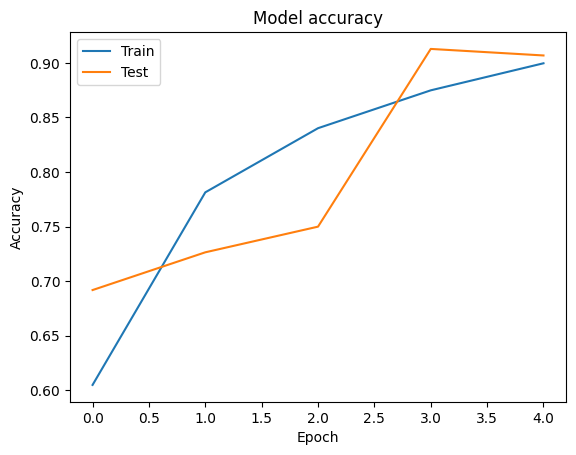

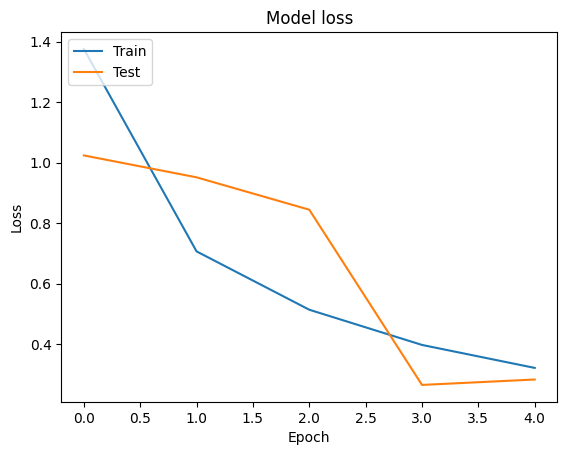

In [18]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [19]:
# Function to Load and Preprocess the Image using Pillow
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    # Load the image
    img = Image.open(image_path)
    # Resize the image
    img = img.resize(target_size)
    # Convert the image to a numpy array
    img_array = np.array(img)
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    # Scale the image values to [0, 1]
    img_array = img_array.astype('float32') / 255.
    return img_array

# Function to Predict the Class of an Image
def predict_image_class(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image(image_path)
    predictions = model.predict(preprocessed_img)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name


In [20]:
# Create a mapping from class indices to class names
class_indices = {v: k for k, v in train_generator.class_indices.items()}

In [21]:
class_indices

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [22]:
# saving the class names as json file
json.dump(class_indices, open('class_indices.json', 'w'))

In [23]:
# Example Usage
# Let's pick an image from the dataset for testing
# Get a list of subdirectories (classes) in the color_dir
class_dirs_for_prediction = os.listdir(color_dir)

# Choose a specific class for the example image
example_class = 'Apple___Apple_scab'
if example_class not in class_dirs_for_prediction:
    print(f"Warning: '{example_class}' not found in dataset. Picking a random class instead.")
    example_class = random.choice(class_dirs_for_prediction)

# Get a list of images in the chosen class directory
images_in_example_class = os.listdir(os.path.join(color_dir, example_class))

# Choose the first image from that class for consistency
example_image_name = images_in_example_class[0]

# Construct the full image path for prediction
image_path = os.path.join(color_dir, example_class, example_image_name)

print(f"Using image for prediction: {image_path}")

predicted_class_name = predict_image_class(model, image_path, class_indices)

# Output the result
print("Predicted Class Name:", predicted_class_name)

Using image for prediction: /kaggle/input/plantvillage-dataset/plantvillage dataset/color/Apple___Apple_scab/5a178d63-372d-48c4-adb8-d616130ba3f0___FREC_Scab 3104.JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 926ms/step
Predicted Class Name: Apple___Apple_scab


In [24]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [25]:
# save the trained model
model.save("plant_disease_model.h5")

In [1]:
import json

class_indices = train_generator.class_indices

with open("class_indices.json", "w") as f:
    json.dump(class_indices, f)

NameError: name 'train_generator' is not defined